In [2]:
import pandas as pd
import numpy as np

import shap
import joblib
import matplotlib.pyplot as plt

In [3]:
X_train = pd.read_csv("../data/processed/X_train_smote.csv")

X_test = pd.read_csv("../data/processed/X_test.csv")

model = joblib.load("../models/final_model.pkl")

In [4]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

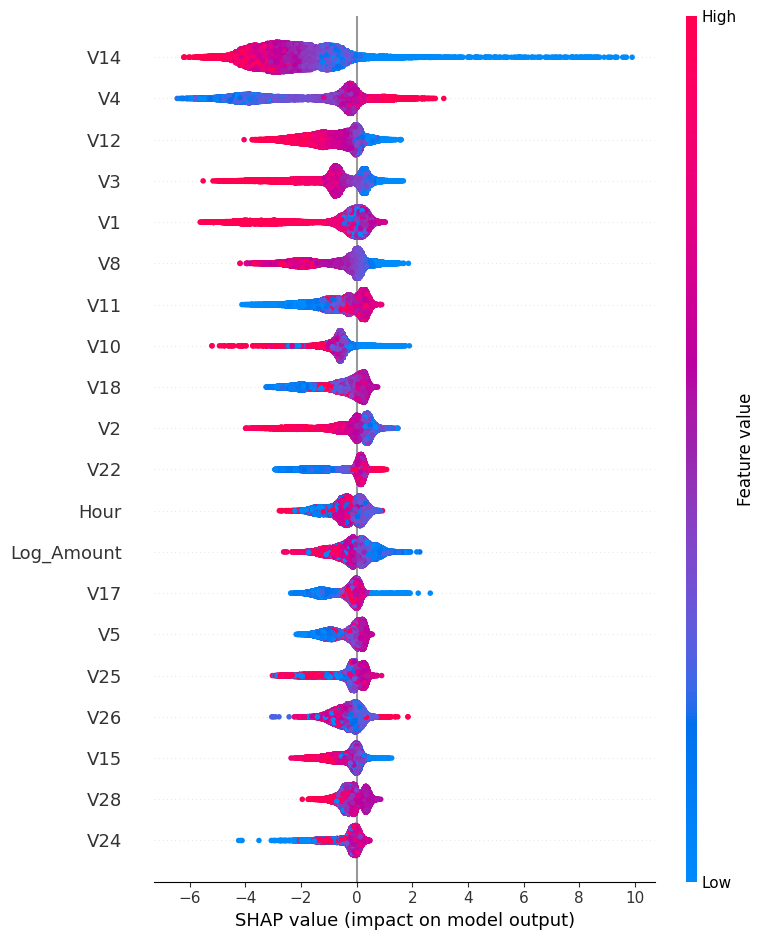

In [5]:
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.savefig(
    "../images/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

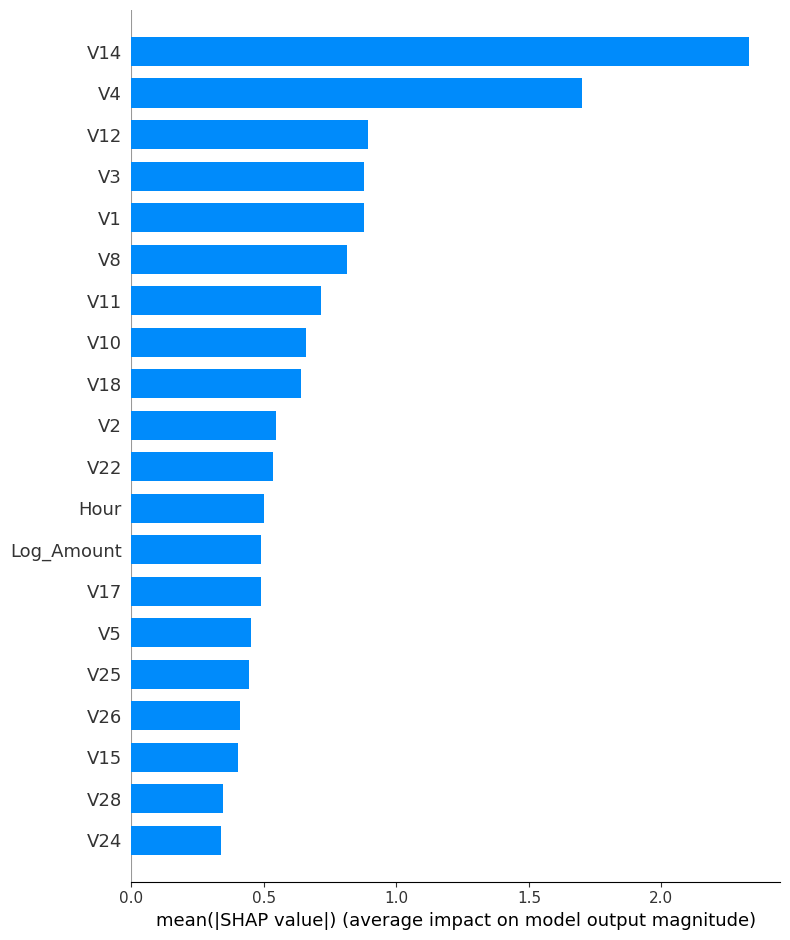

In [6]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.savefig(
    "../images/shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
importance = pd.DataFrame({

    "Feature":X_test.columns,

    "Importance":np.abs(shap_values).mean(axis=0)

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
14,V14,2.331259
4,V4,1.700725
12,V12,0.891255
3,V3,0.878357
1,V1,0.876956
8,V8,0.813410
11,V11,0.715457
10,V10,0.657897
18,V18,0.638674
2,V2,0.546101


In [8]:
importance.to_csv(

    "../reports/shap_feature_importance.csv",

    index=False
)

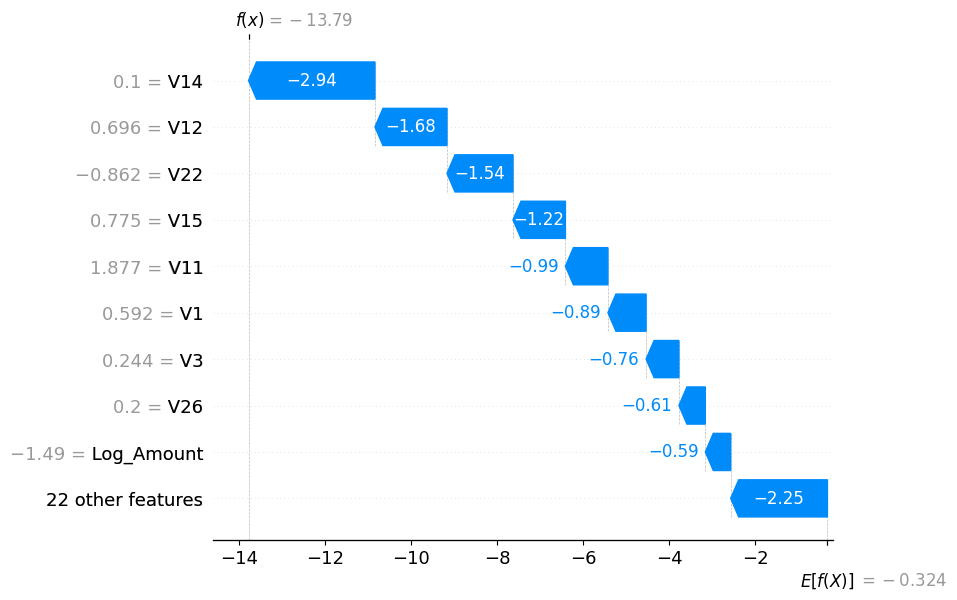

In [9]:
sample = 10

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[sample],

        base_values=explainer.expected_value,

        data=X_test.iloc[sample],

        feature_names=X_test.columns

    ),

    show=False
)

plt.savefig(

    "../images/shap_waterfall.png",

    dpi=300,

    bbox_inches="tight"
)

plt.show()

In [10]:
shap.initjs()

shap.force_plot(

    explainer.expected_value,

    shap_values[0],

    X_test.iloc[0]
)

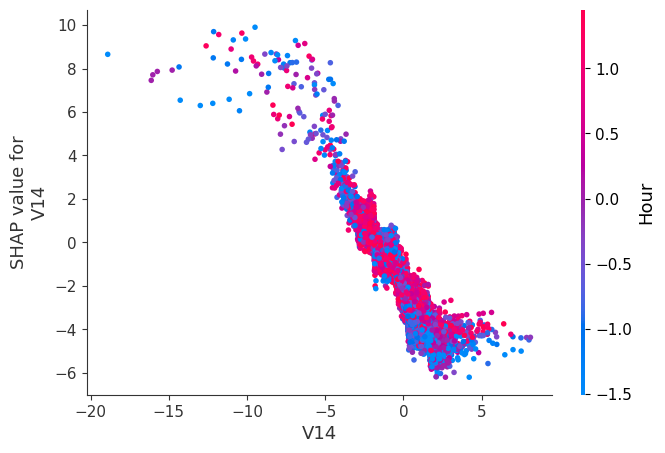

In [11]:
shap.dependence_plot(

    "V14",

    shap_values,

    X_test,

    show=False
)

plt.savefig(

    "../images/shap_dependence_v14.png",

    dpi=300,

    bbox_inches="tight"
)

plt.show()

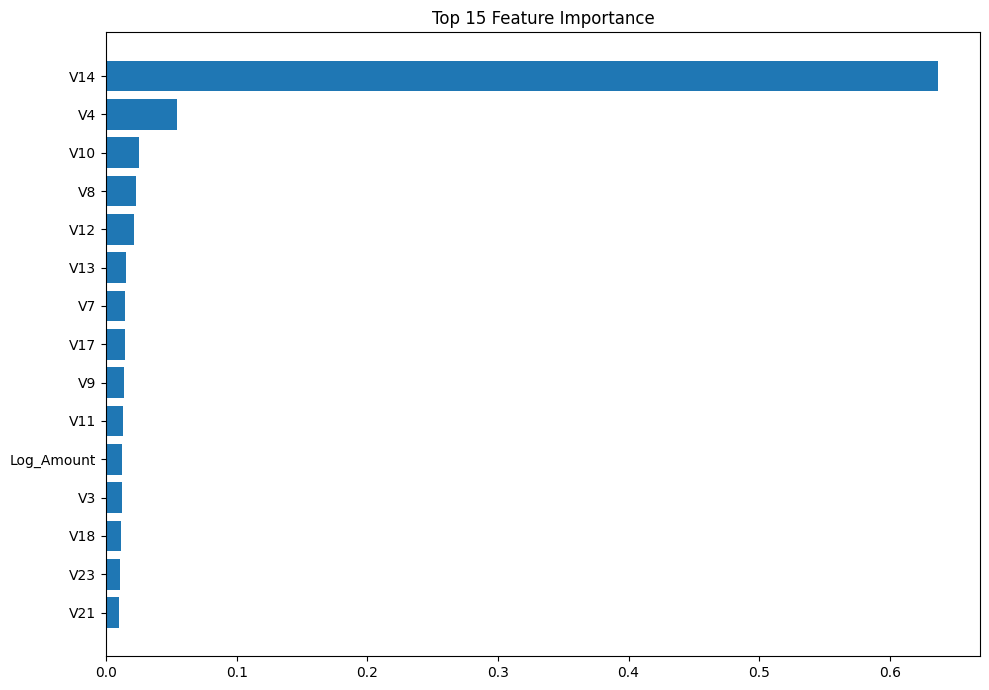

In [12]:
importance = pd.DataFrame({

    "Feature":X_test.columns,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False
)

plt.figure(figsize=(10,7))

plt.barh(

    importance["Feature"][:15],

    importance["Importance"][:15]

)

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance")

plt.tight_layout()

plt.savefig(

    "../images/feature_importance.png",

    dpi=300
)

plt.show()

In [15]:
with open("../reports/explainability_report.md","w") as f:

    f.write("# Explainable AI Report\n\n")

    f.write("## Global Explanation\n")

    f.write("- SHAP Summary Plot\n")

    f.write("- SHAP Feature Importance\n\n")

    f.write("## Local Explanation\n")

    f.write("- Waterfall Plot\n")

    f.write("- Force Plot\n\n")

    f.write("## Key Features\n")

    f.write(importance.head(10).to_markdown(index=False))